#Setup & Data Loading

In [12]:
# Install required libraries (if needed)
!pip install windrose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from windrose import WindroseAxes

# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

# Load data (replace path)
file_path = '/content/drive/MyDrive/Solar_Project/data/sierraleone-bumbuna.csv'
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Data Profiling

In [14]:
# Summary statistics for numeric columns
print("Summary Statistics:")
print(df.describe(include=np.number))

# Missing values analysis
missing_values = df.isna().sum()
missing_percent = (missing_values / len(df)) * 100
print("\nMissing Values (%):")
print(missing_percent.round(2))
high_missing_cols = missing_percent[missing_percent > 5].index.tolist()
print("\nColumns with >5% missing values:", high_missing_cols)

Summary Statistics:
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      201.957515     116.376337     113.720571     206.643095   
std       298.495150     218.652659     158.946032     300.896893   
min       -19.500000      -7.800000     -17.900000       0.000000   
25%        -2.800000      -0.300000      -3.800000       0.000000   
50%         0.300000      -0.100000      -0.100000       3.600000   
75%       362.400000     107.000000     224.700000     359.500000   
max      1499.000000     946.000000     892.000000    1507.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      198.114691      26.319394      79.448857       1.146113   
std       288.889073       4.398605      20.520775       1.239248   
min         0.000000      12.300000       9.900000       0.000000   
25%         0

#Data Cleaning

In [15]:
# Drop non-essential columns (create a copy upfront)
df_clean = df.drop(columns=['Comments']).copy()

# Clip negative values in solar columns using .loc
solar_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB']
df_clean.loc[:, solar_cols] = df_clean[solar_cols].clip(lower=0)

# Outlier detection using Z-scores
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = stats.zscore(df_clean[outlier_cols])
outliers = (abs(z_scores) > 3).any(axis=1)

# Remove outliers (ensure df_clean remains a copy)
df_clean = df_clean[~outliers].copy()  # <── Add .copy() after filtering
print(f"Removed {outliers.sum()} outliers.")

# Impute missing values using .loc
key_cols = ['GHI', 'DNI', 'Tamb', 'RH']
df_clean.loc[:, key_cols] = df_clean[key_cols].fillna(df_clean[key_cols].median())

Removed 16547 outliers.


#Time Series Analysis

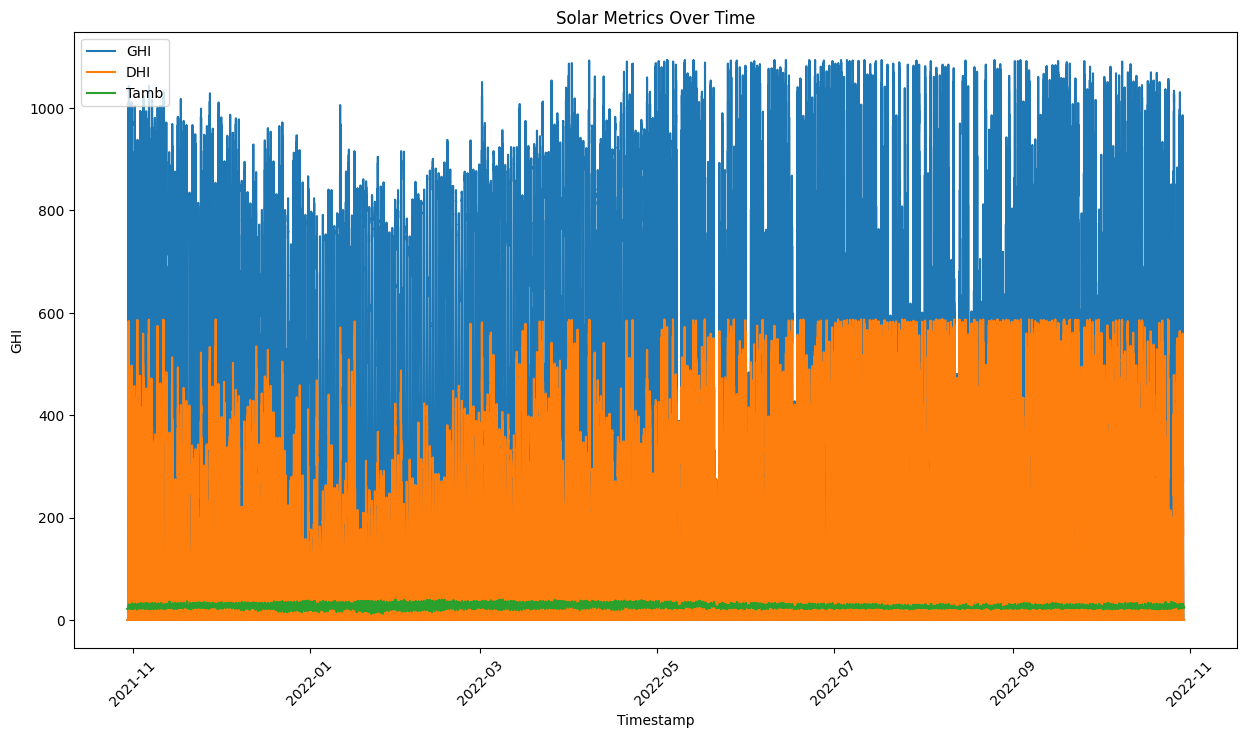

In [16]:
# Convert Timestamp to datetime
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Plot GHI, DHI, Tamb over time
variables = ['GHI', 'DHI', 'Tamb']
plt.figure(figsize=(15, 8))
for var in variables:
    sns.lineplot(x='Timestamp', y=var, data=df_clean, label=var)
plt.title('Solar Metrics Over Time')
plt.xticks(rotation=45)
plt.show()

#Cleaning Impact Analysis

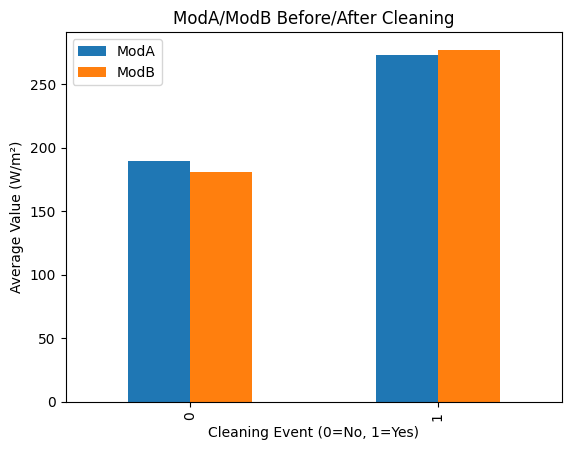

In [17]:
# Group by 'Cleaning' and plot ModA/ModB
cleaning_groups = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
cleaning_groups.plot(kind='bar', title='ModA/ModB Before/After Cleaning')
plt.xlabel('Cleaning Event (0=No, 1=Yes)')
plt.ylabel('Average Value (W/m²)')
plt.show()

#Correlation & Relationships

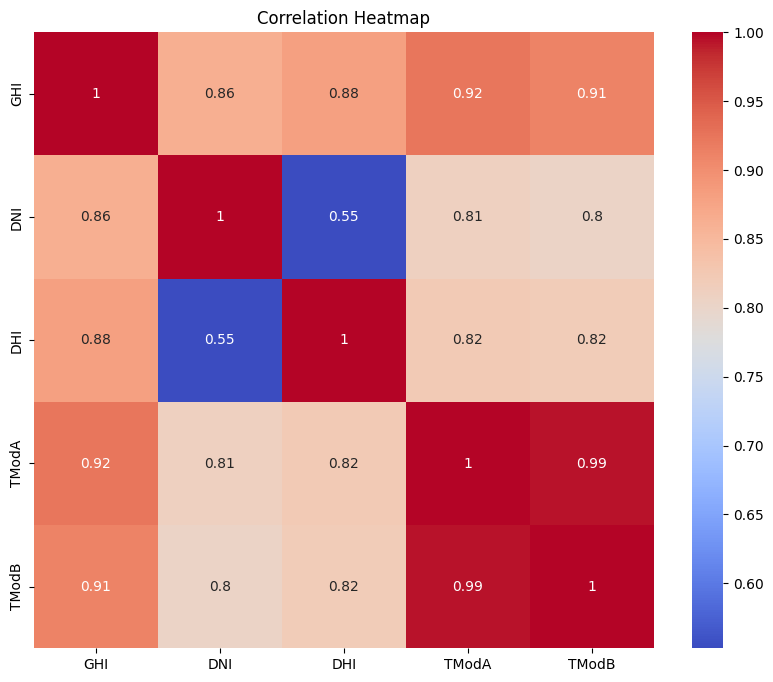

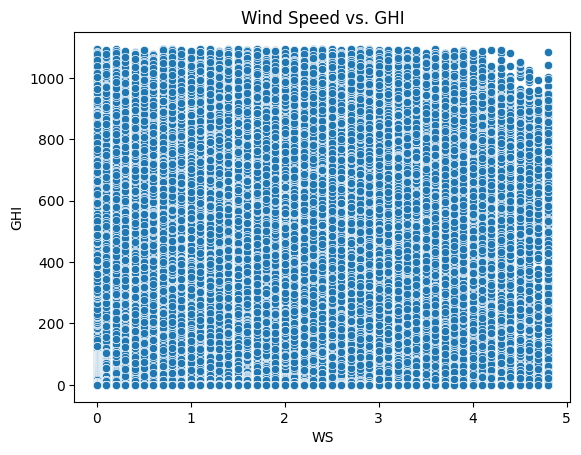

In [18]:
# Heatmap
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
corr_matrix = df_clean[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Scatter plots
sns.scatterplot(x='WS', y='GHI', data=df_clean)
plt.title('Wind Speed vs. GHI')
plt.show()

#Wind & Distribution Analysis

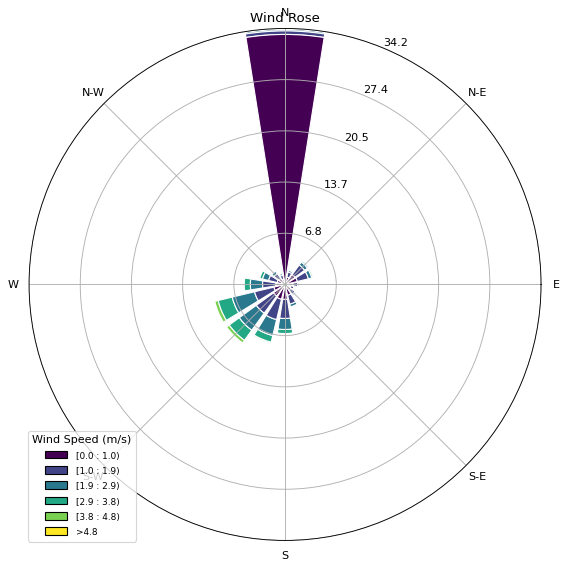

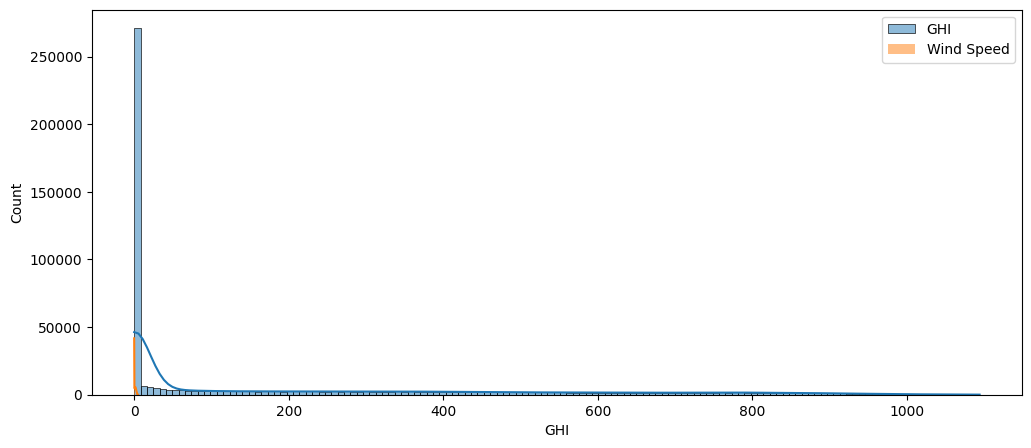

In [19]:
# Wind Rose
ax = WindroseAxes.from_ax()
ax.bar(df_clean['WD'], df_clean['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend(title='Wind Speed (m/s)')
plt.title('Wind Rose')
plt.show()

# Histograms
plt.figure(figsize=(12, 5))
sns.histplot(df_clean['GHI'], kde=True, label='GHI')
sns.histplot(df_clean['WS'], kde=True, label='Wind Speed')
plt.legend()
plt.show()

#Temperature Impact

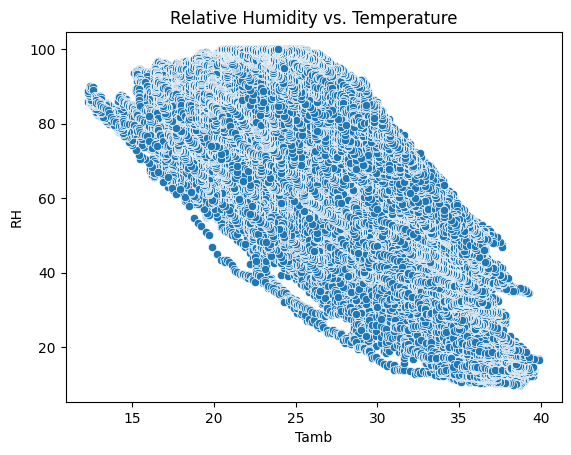

In [20]:
# RH vs. Tamb
sns.scatterplot(x='Tamb', y='RH', data=df_clean)
plt.title('Relative Humidity vs. Temperature')
plt.show()

#Bubble Chart

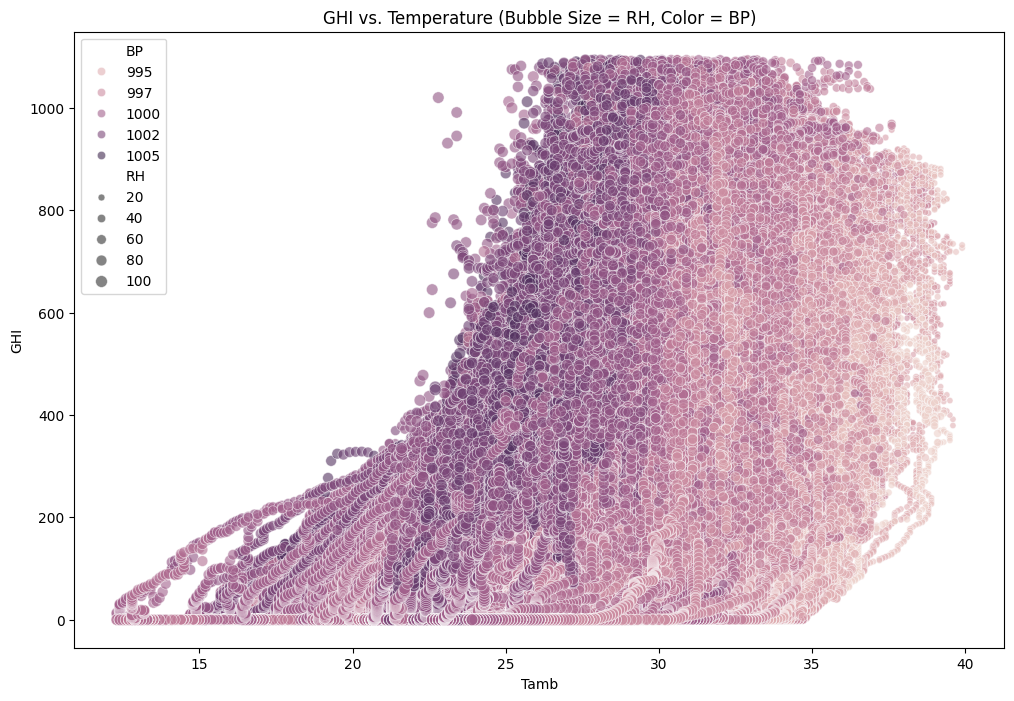

In [21]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Tamb', y='GHI', size='RH', hue='BP', data=df_clean, alpha=0.6)
plt.title('GHI vs. Temperature (Bubble Size = RH, Color = BP)')
plt.show()

#Export Cleaned Data

In [26]:
# Save to data/ folder
import os
os.makedirs('data', exist_ok=True)
df_clean.to_csv('/content/drive/MyDrive/Solar_Project/data/sierra_leone_clean.csv', index=False)
print("Cleaned data saved to data/sierra_leone_clean.csv")

Cleaned data saved to data/sierra_leone_clean.csv
